# Probability and distributions 🎲

## What you will learn in this course 🧐🧐

A distribution is a mathematical recipe that says: *if I sample a value from this process, what is the chance of getting any particular result?* Once you know the distribution, you can predict what tomorrow's data will look like, set realistic targets, detect outliers, and build statistical tests.

By the end of this lecture, you will be able to:
- Define a random variable $X$ and identify the distribution that fits its behavior.
- Compute probabilities and quantiles for the binomial, normal, exponential, and Poisson distributions using SciPy.
- Interpret the parameters of each distribution and their effect on the shape.
- Apply the 68-95-99.7 rule to detect outliers in normally distributed data.
- Demonstrate the Central Limit Theorem with a Python simulation.
- Visualize any distribution and overlay theoretical curves with seaborn.

<Note type="important" title="Focus on understanding the concepts"> 

Plots are there to help you visualize the concepts. Do not focus on the code to create the plots, but rather on what the plots are showing you about the relationships between variables. We do not expect you to be able to write the code to create the plots, but we do expect you to understand what the plots are showing you about the relationships between variables.

</Note>

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import binom, norm, expon, poisson
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean default style for all charts
sns.set_theme(style="whitegrid")

## Business context

<img src="https://ai-fullstack-assets.s3.eu-west-3.amazonaws.com/M02-EDA/pulse_social_logo.png" alt="PulseSocial logo"/>

We continue working with **PulseSocial**, the social media analytics platform. We will model real PulseSocial questions using four classic distributions: how many promoted posts get clicked, how long users spend on the platform, how many likes a post collects, and how many hashtags users add per post.

## Binomial distribution for discrete data

The marketing team wants to model **how many of the next 10 promoted posts will be clicked** when each post has a 50% chance of being clicked. Each click is an **independent yes/no event**: clicked or not clicked. We need a distribution that models the **count of successes** in a fixed number of yes/no trials.

This is exactly what the **binomial distribution** answers.

Let $X$ be the **number of successes** in $n$ independent yes/no trials, where each trial has the same probability $p$ of success. Then $X$ follows a **binomial distribution**, written:

$$X \sim B(n, p)$$

The probability of getting **exactly $k$ successes** is given by the **probability mass function** (PMF):

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k} = \frac{n!}{k! \, (n-k)!} \, p^k \, (1-p)^{n-k}$$

for $k = 0, 1, 2, \ldots, n$, where $\binom{n}{k}$ is the **binomial coefficient** (read as "n choose k") and counts the number of ways to pick $k$ successes from $n$ trials.

The expected value (mean) and variance are:

$$E[X] = np$$
$$\text{Var}(X) = np(1-p)$$

The binomial distribution has **two parameters**:
- $n$ = the number of trials (a positive integer).
- $p$ = the probability of success on each trial (a number between 0 and 1).

This distribution is fundamental for modeling yes/no outcomes: ad clicks, conversions, pass/fail tests, defective items in a batch, and any binary event repeated many times.


### A single trial (Bernoulli)

When $n = 1$, the binomial distribution simplifies to a single yes/no trial. This special case is called a **Bernoulli trial**. The result is either 0 (failure) or 1 (success). The next code block simulates one such trial with $p = 0.5$.


In [2]:
# Simulate a single Bernoulli trial: 1 trial, p = 0.5
single_trial = binom.rvs(n=1, p=0.5, size=1)
print(f"Result of one Bernoulli trial (n=1, p=0.5): {single_trial}")

# Run 20 such trials and count the successes
twenty_trials = binom.rvs(n=1, p=0.5, size=20)
print(f"Twenty Bernoulli trials: {twenty_trials}")
print(f"Number of successes:     {twenty_trials.sum()}")


Result of one Bernoulli trial (n=1, p=0.5): [1]
Twenty Bernoulli trials: [0 0 0 1 1 0 1 0 1 1 1 0 0 0 1 0 1 0 1 0]
Number of successes:     9


`binom.rvs(n=1, p=0.5, size=1)` draws **one random sample** from $B(1, 0.5)$. Each draw returns either 0 or 1. The `rvs` stands for **random variates**.

Run the cell several times. You will see both 0 and 1 appear, each about half the time. This is the smallest possible random experiment.

When we draw 20 such trials, we should see roughly 10 successes on average, because the expected value is $E[X] = np = 1 \times 0.5 = 0.5$ per trial, and over 20 trials the expected total is 10.


### The full PMF of $B(10, 0.5)$

Now consider $n = 10$ trials. The random variable $X$ can take any integer value from 0 to 10. The probability mass function (PMF) tells us the probability of each one. We will plot the full PMF with seaborn.

In [3]:
# Compute the PMF of B(n=10, p=0.5) for every possible k
n_trials = 10
p_success = 0.5

# All possible numbers of successes: 0, 1, 2, ..., 10
k_values = np.arange(0, n_trials + 1)

# Probability of each k
pmf_values = binom.pmf(k_values, n_trials, p_success)

# Print a small table of the probabilities
for k in k_values:
    prob = pmf_values[k]
    print(f"P(X = {k:2d}) = {prob:.4f}")

# Expected value and variance
expected_value = n_trials * p_success
variance_value = n_trials * p_success * (1 - p_success)
print(f"\nExpected value E[X] = np = {expected_value}")
print(f"Variance Var(X) = np(1-p) = {variance_value}")


P(X =  0) = 0.0010
P(X =  1) = 0.0098
P(X =  2) = 0.0439
P(X =  3) = 0.1172
P(X =  4) = 0.2051
P(X =  5) = 0.2461
P(X =  6) = 0.2051
P(X =  7) = 0.1172
P(X =  8) = 0.0439
P(X =  9) = 0.0098
P(X = 10) = 0.0010

Expected value E[X] = np = 5.0
Variance Var(X) = np(1-p) = 2.5


`binom.pmf(k_values, n_trials, p_success)` evaluates the PMF formula for every value of $k$ in our array. The result is an array of probabilities, one for each $k$. This is the same calculation as the textbook formula, just done by SciPy.

The probabilities sum to 1 (every possible outcome is covered). The largest probabilities cluster around $k = 5$, which is exactly $E[X] = np = 10 \times 0.5 = 5$. Outcomes far from 5 (like 0 or 10) have very small probabilities.


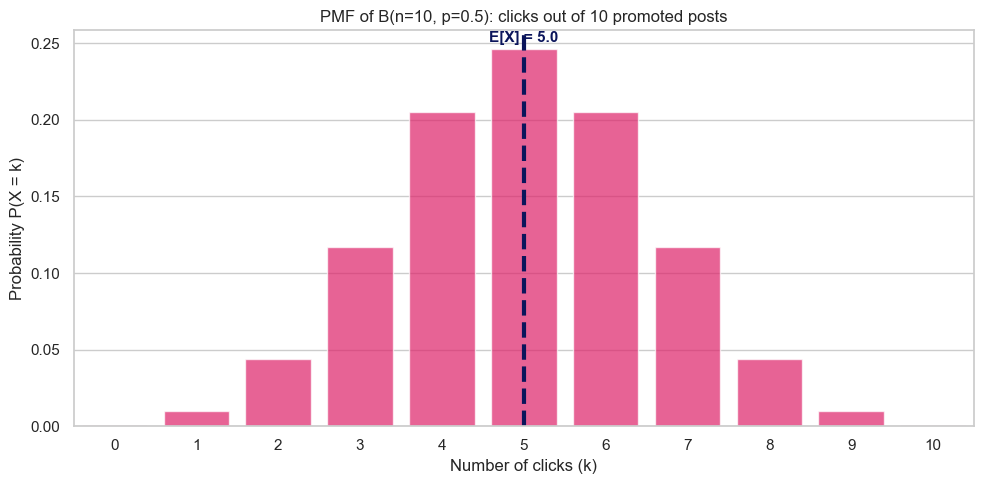

In [4]:
# Plot the PMF as a bar chart with seaborn
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(x=k_values, y=pmf_values, color="#FE0162", alpha=0.7, ax=ax)

# Add a vertical line for the expected value
ax.axvline(expected_value, color="#0B155B", linestyle="--", linewidth=3)
ax.text(expected_value, max(pmf_values) * 1.02,
        f"E[X] = {expected_value}",
        color="#0B155B", ha="center", fontsize=11, fontweight="bold")

# Tidy up the chart
ax.set_title("PMF of B(n=10, p=0.5): clicks out of 10 promoted posts")
ax.set_xlabel("Number of clicks (k)")
ax.set_ylabel("Probability P(X = k)")

plt.tight_layout()
plt.show()

The chart shows the classic **symmetric bell** shape that the binomial takes when $p = 0.5$. The peak is at $k = 5$, the expected value. The probabilities drop off quickly on both sides. Getting 0 or 10 successes is very rare, less than 0.1% each.


### Independence requirement

The binomial distribution requires that trials be **independent**. The probability of success on trial $i$ must not depend on the outcomes of previous trials. Formally:

$$P(X_i = 1 \mid X_1, X_2, \ldots, X_{i-1}) = p$$

If this fails, the binomial does not apply. The classic example is **sampling without replacement**. Once you remove an item from the pool, the composition changes, and the next trial is no longer independent of the previous one.


In [5]:
# Sales team: 4 people
sales_team = pd.Series(["Amir", "Brian", "Claire", "Damian"])

# With replacement: each pick is independent
np.random.seed(0)
with_replacement = sales_team.sample(10, replace=True)
print("With replacement (independent — names can repeat):")
print(with_replacement.tolist())

# Without replacement: max sample size is 4 (the size of the pool)
without_replacement = sales_team.sample(4, replace=False)
print("\nWithout replacement (NOT independent — names cannot repeat, max 4):")
print(without_replacement.tolist())


With replacement (independent — names can repeat):
['Amir', 'Damian', 'Brian', 'Amir', 'Damian', 'Damian', 'Damian', 'Damian', 'Brian', 'Damian']

Without replacement (NOT independent — names cannot repeat, max 4):
['Damian', 'Amir', 'Claire', 'Brian']


## Normal distribution for continuous data

The PulseSocial product team wants to model **daily session times** for users. After looking at the data, they notice it forms a **bell-shape**: most users spend close to the average time, some spend a bit less, some a bit more, and very few are extreme. This pattern fits the most famous distribution in statistics: the **Normal distribution**.

A random variable $X$ follows a **Normal distribution** (also called **Gaussian distribution** or **bell curve**) with mean $\mu$ and standard deviation $\sigma$, written:

$$X \sim \mathcal{N}(\mu, \sigma^2)$$

Its **probability density function** (PDF) is:

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \, e^{-\frac{1}{2} \left(\frac{x - \mu}{\sigma}\right)^2}$$

The expected value and variance are:

$$E[X] = \mu$$
$$\text{Var}(X) = \sigma^2$$

The Normal distribution has **two parameters**:
- $\mu$ (mu) is the **mean**. It controls **where** the curve is centered.
- $\sigma$ (sigma) is the **standard deviation**. It controls **how wide** the curve is. A small $\sigma$ gives a tall, narrow bell. A large $\sigma$ gives a short, wide bell.

The shape is **symmetric** around the mean. Half the values fall below $\mu$, half fall above. Most values stay close to $\mu$. Values far from $\mu$ are rare.

The next code block simulates daily session times (in minutes) for 1,000 PulseSocial users. We assume the average session is **25 minutes** with a standard deviation of **8 minutes**.


In [6]:
np.random.seed(42)

mu = 25       # mean session time in minutes
sigma = 8     # standard deviation in minutes

# Generate 1000 daily session times from N(25, 8^2)
session_times = np.random.normal(loc=mu, scale=sigma, size=1000)

# Sample statistics
sample_mean = session_times.mean()
sample_std = session_times.std()
print(f"Sample mean: {sample_mean:.2f} minutes  (theory: mu = {mu})")
print(f"Sample std:  {sample_std:.2f} minutes  (theory: sigma = {sigma})")

# Business questions
short_sessions = (session_times < 15).sum()
long_sessions = (session_times > 40).sum()
print(f"\nShort sessions (under 15 min): {short_sessions}")
print(f"Long sessions (over 40 min):  {long_sessions}")


Sample mean: 25.15 minutes  (theory: mu = 25)
Sample std:  7.83 minutes  (theory: sigma = 8)

Short sessions (under 15 min): 98
Long sessions (over 40 min):  32


The sample mean and sample std come out very close to 25 and 8, which confirms the parameters. They are not exact because we drew a finite sample (1,000 users). With more users, the match would be even tighter.

`(session_times < 15).sum()` counts how many users had short sessions. The comparison creates a boolean array; `.sum()` counts the `True` values (each `True` counts as 1). About 10% of users fall below 15 minutes, which matches what we expect from a Normal with $\mu = 25$, $\sigma = 8$.

We plot the histogram of our 1,000 simulated values and overlay the **theoretical** PDF curve. The two should match closely. We use seaborn for clean statistical plots that work well in any reporting tool.


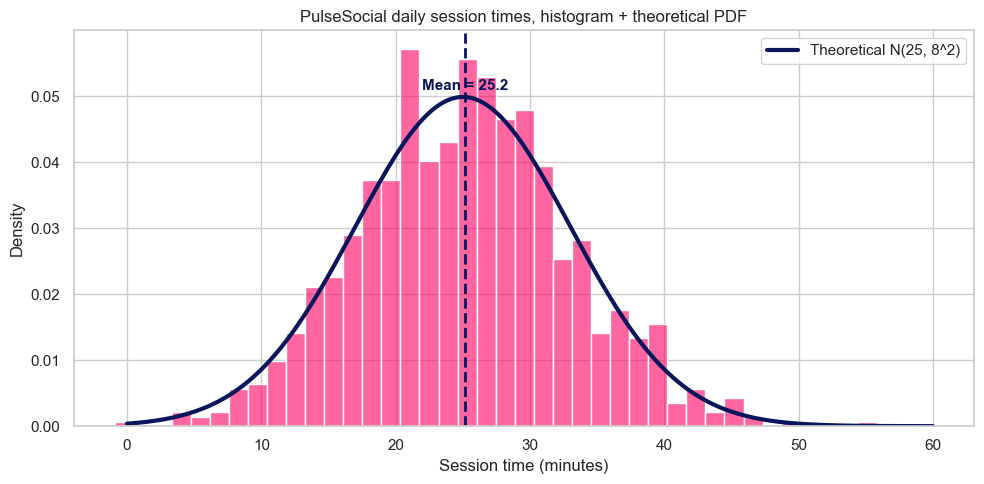

In [7]:
# Build the figure: histogram of the sample with the theoretical PDF on top
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram normalized to a density, so it can be compared to the PDF curve
sns.histplot(x=session_times, bins=40, stat="density",
             color="#FE0162", alpha=0.6, ax=ax)

# Theoretical Normal PDF curve
x_curve = np.linspace(0, 60, 200)
y_curve = norm.pdf(x_curve, loc=mu, scale=sigma)
ax.plot(x_curve, y_curve, color="#0B155B", linewidth=3,
        label="Theoretical N(25, 8^2)")

# Mean line
ax.axvline(sample_mean, color="#0B155B", linestyle="--", linewidth=2)
ax.text(sample_mean, max(y_curve) * 1.02,
        f"Mean = {sample_mean:.1f}",
        color="#0B155B", ha="center", fontsize=11, fontweight="bold")

ax.set_title("PulseSocial daily session times, histogram + theoretical PDF")
ax.set_xlabel("Session time (minutes)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

The mean line sits at the **center** of the bell, not at the edge. This is a defining property of the Normal distribution: the **mean, median, and mode all coincide** at the same value, $\mu$.


### The 68-95-99.7 rule

The Normal distribution has a famous property called the **68-95-99.7 rule** (also known as the **empirical rule**):

- About **68%** of values fall within **1 standard deviation** ($\sigma$) of the mean.
- About **95%** of values fall within **2 standard deviations** ($2\sigma$) of the mean.
- About **99.7%** of values fall within **3 standard deviations** ($3\sigma$) of the mean.

> This rule is the most useful single fact about the Normal distribution. You will use it constantly to set thresholds, detect outliers, and build confidence intervals.

In our PulseSocial example, $\mu = 25$ and $\sigma = 8$. So:
- 68% of users have sessions between 17 and 33 minutes.
- 95% of users have sessions between 9 and 41 minutes.
- 99.7% of users have sessions between 1 and 49 minutes.

Anything outside the $3\sigma$ range is **rare**. Such values may signal an unusual user, a bot, or a tracking bug. The next code block verifies the rule on our 1,000-user sample.


In [8]:
# Compute the boundaries for 1, 2, and 3 standard deviations
boundary_1sigma_low = mu - sigma
boundary_1sigma_high = mu + sigma
boundary_2sigma_low = mu - 2 * sigma
boundary_2sigma_high = mu + 2 * sigma
boundary_3sigma_low = mu - 3 * sigma
boundary_3sigma_high = mu + 3 * sigma

# Boolean masks for each range
within_1sigma_mask = (session_times >= boundary_1sigma_low) & (session_times <= boundary_1sigma_high)
within_2sigma_mask = (session_times >= boundary_2sigma_low) & (session_times <= boundary_2sigma_high)
within_3sigma_mask = (session_times >= boundary_3sigma_low) & (session_times <= boundary_3sigma_high)

# Convert to percentages
percent_1sigma = within_1sigma_mask.mean() * 100
percent_2sigma = within_2sigma_mask.mean() * 100
percent_3sigma = within_3sigma_mask.mean() * 100

print(f"Within 1 sigma ({boundary_1sigma_low}-{boundary_1sigma_high} min): {percent_1sigma:.1f}%  (theory: 68%)")
print(f"Within 2 sigma ({boundary_2sigma_low}-{boundary_2sigma_high} min): {percent_2sigma:.1f}%  (theory: 95%)")
print(f"Within 3 sigma ({boundary_3sigma_low}-{boundary_3sigma_high} min): {percent_3sigma:.1f}%  (theory: 99.7%)")


Within 1 sigma (17-33 min): 69.8%  (theory: 68%)
Within 2 sigma (9-41 min): 95.9%  (theory: 95%)
Within 3 sigma (1-49 min): 99.7%  (theory: 99.7%)


The printed percentages should be very close to 68%, 95%, and 99.7%. Small differences are normal because we are looking at a sample of 1,000 values, not the full theoretical distribution.



The next chart draws the theoretical Normal PDF and shades the three regions. You can see at a glance how much of the area sits inside each band.


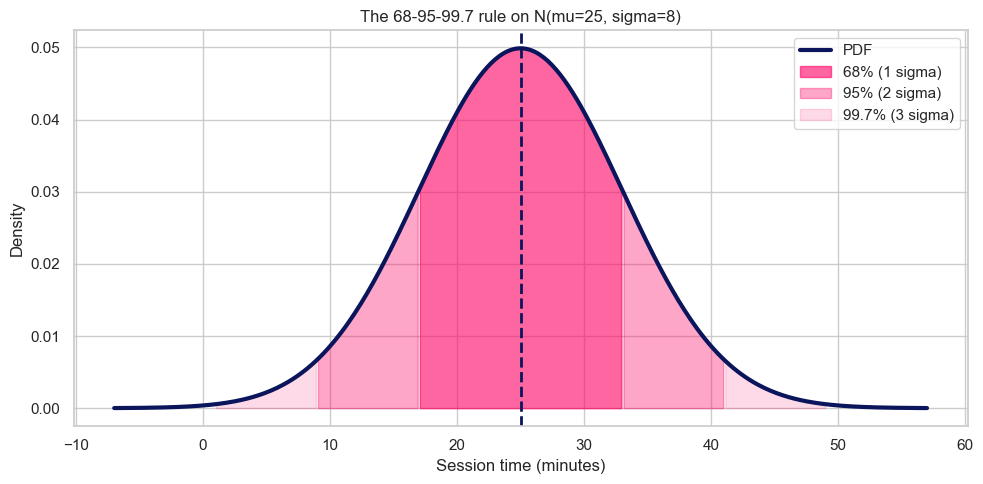

In [9]:
# Build the theoretical PDF curve
x_curve = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
y_curve = norm.pdf(x_curve, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(10, 5))

# Full PDF curve
ax.plot(x_curve, y_curve, color="#0B155B", linewidth=3, label="PDF")

# Shade the 1-sigma region (darker pink)
mask_1s = (x_curve >= boundary_1sigma_low) & (x_curve <= boundary_1sigma_high)
ax.fill_between(x_curve[mask_1s], 0, y_curve[mask_1s],
                color="#FE0162", alpha=0.6, label="68% (1 sigma)")

# Shade the 2-sigma region (medium pink), outside 1-sigma
mask_2s_left = (x_curve >= boundary_2sigma_low) & (x_curve < boundary_1sigma_low)
mask_2s_right = (x_curve > boundary_1sigma_high) & (x_curve <= boundary_2sigma_high)
ax.fill_between(x_curve[mask_2s_left], 0, y_curve[mask_2s_left],
                color="#FE0162", alpha=0.35, label="95% (2 sigma)")
ax.fill_between(x_curve[mask_2s_right], 0, y_curve[mask_2s_right],
                color="#FE0162", alpha=0.35)

# Shade the 3-sigma region (light pink), outside 2-sigma
mask_3s_left = (x_curve >= boundary_3sigma_low) & (x_curve < boundary_2sigma_low)
mask_3s_right = (x_curve > boundary_2sigma_high) & (x_curve <= boundary_3sigma_high)
ax.fill_between(x_curve[mask_3s_left], 0, y_curve[mask_3s_left],
                color="#FE0162", alpha=0.15, label="99.7% (3 sigma)")
ax.fill_between(x_curve[mask_3s_right], 0, y_curve[mask_3s_right],
                color="#FE0162", alpha=0.15)

# Mean line
ax.axvline(mu, color="#0B155B", linestyle="--", linewidth=2)

ax.set_title(f"The 68-95-99.7 rule on N(mu={mu}, sigma={sigma})")
ax.set_xlabel("Session time (minutes)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

The dark inner band covers about 68% of the area. Adding the medium band brings it to 95%. Adding the lightest band brings it to 99.7%. Anything outside the lightest band is in the **0.3% tail** and worth investigating.

<Note type="info">

In real business work, the 68-95-99.7 rule helps you spot **outliers**. If a user's session time is 4 standard deviations above the mean, that is extremely unusual. It happens less than 0.01% of the time by chance. You should investigate: is it a bot, a power user, or a bug in your tracking?

</Note>


<Note type="tip">

The Normal distribution shows up everywhere in statistics, even when the original data is **not** Normal. The reason is the **Central Limit Theorem** (CLT):

> If you take many random samples from any distribution and compute the **mean** of each sample, the distribution of those sample means will be approximately Normal. This holds even if the original data is heavily skewed, discrete, or strange-looking.

In practical terms: when you compute averages from data, those averages tend to follow a Normal distribution. This is why the Normal distribution is the foundation of:
- **Confidence intervals** for the mean.
- **A/B testing** to compare two groups.
- **Hypothesis tests** like the t-test and z-test.

</Note>

## Exponential distribution for skewed data

The PulseSocial growth team needs to model **how long it takes between two consecutive sign-ups** during peak hours, and the **likes per post** for organic content. Both of these have the same shape: most values cluster near zero, but a few are large. The distribution that captures this is the **Exponential distribution**.

A random variable $X$ follows an **Exponential distribution** with rate parameter $\lambda > 0$, written:

$$X \sim \text{Exp}(\lambda)$$

Its **probability density function** (PDF) is:

$$f(x) = \lambda e^{-\lambda x} \quad \text{for } x \geq 0$$

The expected value and variance are:

$$E[X] = \frac{1}{\lambda}$$
$$\text{Var}(X) = \frac{1}{\lambda^2}$$

The exponential distribution has **one parameter**, $\lambda$, called the **rate**. The mean is the reciprocal of the rate. A high rate ($\lambda$ large) means events happen fast and the mean wait time is short.

In NumPy and SciPy, the parameter is often specified as $\beta = 1 / \lambda$, called the **scale**. So `np.random.exponential(scale=100)` generates samples where $E[X] = 100$, which means $\lambda = 0.01$.

Social media metrics like follower counts, likes, and shares often follow exponential patterns. So do customer wait times, time between failures, and inter-arrival times.


In [10]:
# Generate 1000 likes-per-post values from Exp(lambda = 1/100)
np.random.seed(7)
exponential_sample = np.random.exponential(scale=100, size=1000)

print(f"Sample mean:   {exponential_sample.mean():.1f}  (theory: 1/lambda = 100)")
print(f"Sample median: {np.median(exponential_sample):.1f}")
print(f"Values over 300: {(exponential_sample > 300).sum()}")


Sample mean:   98.6  (theory: 1/lambda = 100)
Sample median: 66.7
Values over 300: 47


`np.random.exponential(scale=100, size=1000)` generates 1,000 samples from an exponential distribution with mean 100. The `scale` parameter is $\beta = 1/\lambda$, so $\lambda = 0.01$.

The sample mean is close to 100, as expected. But the **median is much lower**, around 70. The mean is being pulled to the right by the long tail. This is the classic signature of right-skewed data.

About 5% of values exceed 300, which is 3 times the mean. In a Normal distribution, this would be extremely rare. In an exponential distribution, it is normal.


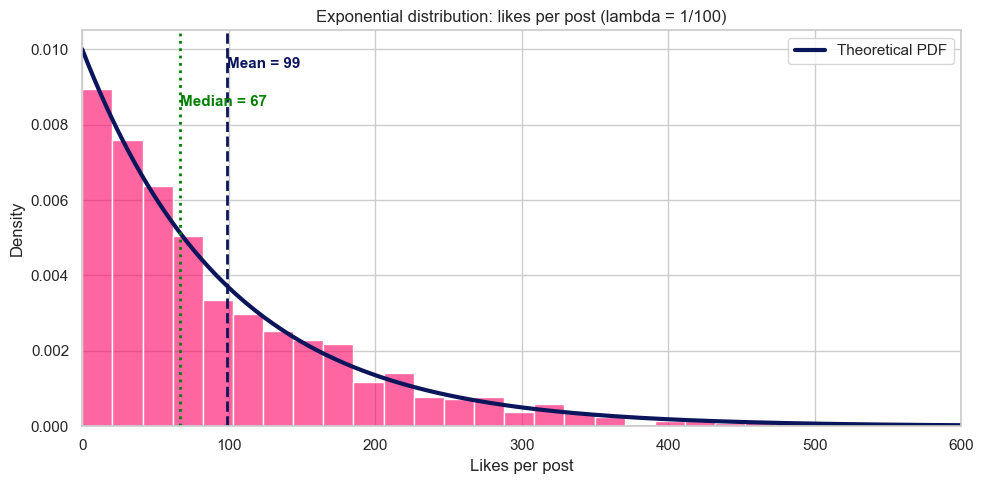

In [11]:
# Plot the histogram with the theoretical PDF on top
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of the sample, normalized to density
sns.histplot(x=exponential_sample, bins=40, stat="density",
             color="#FE0162", alpha=0.6, ax=ax)

# Theoretical PDF
x_curve = np.linspace(0, 600, 300)
lambda_param = 1 / 100
y_curve = lambda_param * np.exp(-lambda_param * x_curve)
ax.plot(x_curve, y_curve, color="#0B155B", linewidth=3,
        label="Theoretical PDF")

# Mark mean and median
sample_mean_exp = exponential_sample.mean()
sample_median_exp = np.median(exponential_sample)

ax.axvline(sample_mean_exp, color="#0B155B", linestyle="--", linewidth=2)
ax.text(sample_mean_exp, max(y_curve) * 0.95,
        f"Mean = {sample_mean_exp:.0f}",
        color="#0B155B", fontsize=11, fontweight="bold")

ax.axvline(sample_median_exp, color="green", linestyle=":", linewidth=2)
ax.text(sample_median_exp, max(y_curve) * 0.85,
        f"Median = {sample_median_exp:.0f}",
        color="green", fontsize=11, fontweight="bold")

ax.set_title("Exponential distribution: likes per post (lambda = 1/100)")
ax.set_xlabel("Likes per post")
ax.set_ylabel("Density")
ax.set_xlim(0, 600)
ax.legend()

plt.tight_layout()
plt.show()

The histogram shows the classic exponential shape: a tall bar near zero, then a smooth decay to the right. The theoretical PDF (the dark blue curve) matches the histogram closely.

The **median line** sits to the **left** of the mean line. This is the visual fingerprint of a right-skewed distribution. The mean is pulled to the right by the long tail. The median better describes the typical post.

This pattern mirrors real social media dynamics: most users have modest engagement, while a few have very high engagement. Reporting only the mean overstates the typical user's experience.


## Poisson distribution for count data

The PulseSocial content team wants to model the **number of hashtags users add per post**, the **number of comments a post receives in its first hour**, and the **number of characters in a user bio**. These are all **counts** of events occurring at a constant average rate. The right tool is the **Poisson distribution**.

A random variable $X$ follows a **Poisson distribution** with rate parameter $\lambda > 0$, written:

$$X \sim \text{Poisson}(\lambda)$$

Its **probability mass function** (PMF) is:

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!} \quad \text{for } k = 0, 1, 2, \ldots$$

The expected value and variance are **both equal to** $\lambda$:

$$E[X] = \text{Var}(X) = \lambda$$

This equality is a unique signature of the Poisson distribution. If you measure a count and see that the sample mean and sample variance are roughly equal, the Poisson is a strong candidate.

The Poisson distribution applies when:
1. Events occur **independently** of each other.
2. Events occur at a **constant average rate**.
3. The count cannot be negative; it has a lower bound of zero.


In [12]:
# Generate three Poisson-distributed datasets with different lambda
np.random.seed(2024)

# Lambda = 8: hashtags per post
hashtag_counts = np.random.poisson(lam=8, size=1000)
print("Hashtag count distribution (lambda = 8):")
print(f"  Mean: {hashtag_counts.mean():.2f}  (theory: 8)")
print(f"  Variance: {hashtag_counts.var():.2f}  (theory: 8)")
print(f"  Posts with 0 hashtags:   {(hashtag_counts == 0).sum()}")
print(f"  Posts with 15+ hashtags: {(hashtag_counts >= 15).sum()}")

# Lambda = 3: comments per post in first hour
comment_counts = np.random.poisson(lam=3, size=1000)
print(f"\nComment count distribution (lambda = 3):")
print(f"  Mean: {comment_counts.mean():.2f}")
print(f"  Posts with 0 comments:  {(comment_counts == 0).sum()}")
print(f"  Posts with 10+ comments: {(comment_counts >= 10).sum()}")

# Lambda = 80: bio length in characters
bio_lengths = np.random.poisson(lam=80, size=1000)
print(f"\nBio length distribution (lambda = 80):")
print(f"  Mean: {bio_lengths.mean():.2f}")
print(f"  Empty bios: {(bio_lengths == 0).sum()}")
print(f"  Long bios (150+ chars): {(bio_lengths >= 150).sum()}")


Hashtag count distribution (lambda = 8):
  Mean: 8.11  (theory: 8)
  Variance: 7.91  (theory: 8)
  Posts with 0 hashtags:   2
  Posts with 15+ hashtags: 17

Comment count distribution (lambda = 3):
  Mean: 3.03
  Posts with 0 comments:  50
  Posts with 10+ comments: 1

Bio length distribution (lambda = 80):
  Mean: 79.89
  Empty bios: 0
  Long bios (150+ chars): 0



For each dataset, we check the **mean-variance equality**.The sample mean and sample variance should both be very close to $\lambda$. They are not exactly equal because of sampling noise, but they are close.

Notice that very few posts have **zero** hashtags when $\lambda = 8$ (the mean is far from zero). But about 5% of posts have **zero** comments when $\lambda = 3$ (the mean is close to zero). This shows how $\lambda$ controls the proportion of zeros.


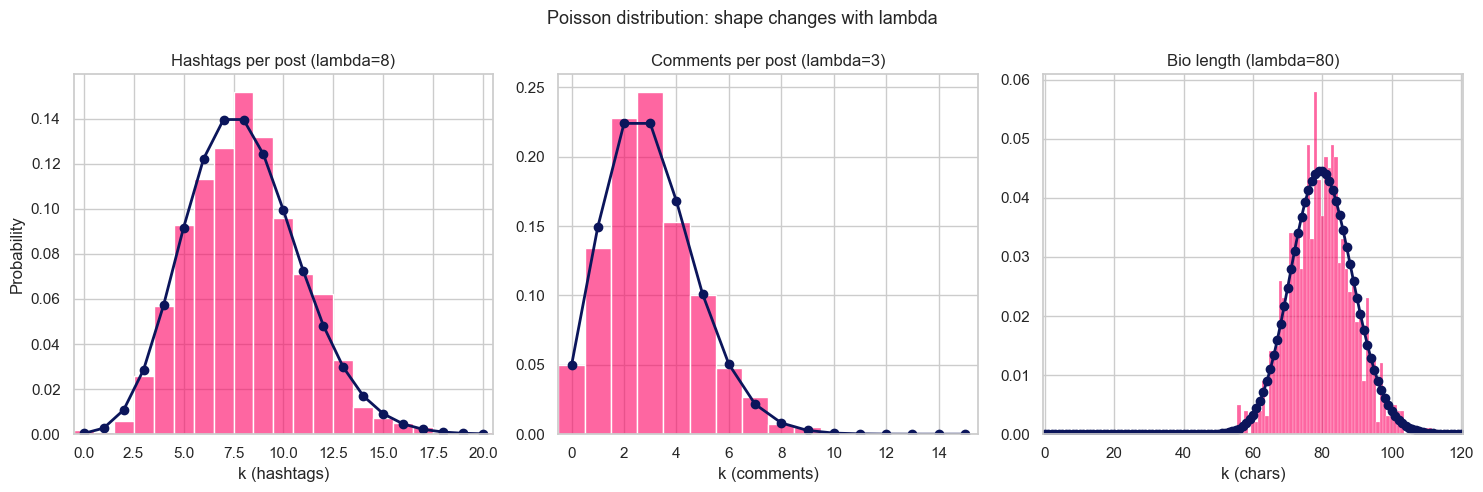

In [13]:
# Plot all three Poisson distributions side by side, with theoretical PMF
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))


def add_poisson_subplot(ax, sample_data, lam, x_max, x_label):
    """Draw one histogram and overlay the theoretical PMF on the given axis."""
    # Bins of width 1, centered on integers, so each bar matches one k value
    bin_edges = np.arange(-0.5, x_max + 1.5, 1)
    sns.histplot(x=sample_data, bins=bin_edges, stat="probability",
                 color="#FE0162", alpha=0.6, ax=ax)

    # Theoretical PMF as markers + line
    k_range = np.arange(0, x_max + 1)
    pmf_theory = poisson.pmf(k_range, mu=lam)
    ax.plot(k_range, pmf_theory, color="#0B155B", linewidth=2,
            marker="o", markersize=6)

    ax.set_xlabel(x_label)
    ax.set_xlim(-0.5, x_max + 0.5)


# Three different lambdas show how the shape changes
add_poisson_subplot(axes[0], hashtag_counts, lam=8,  x_max=20,  x_label="k (hashtags)")
add_poisson_subplot(axes[1], comment_counts, lam=3,  x_max=15,  x_label="k (comments)")
add_poisson_subplot(axes[2], bio_lengths,    lam=80, x_max=120, x_label="k (chars)")

# Subplot titles and shared y-axis label
axes[0].set_title("Hashtags per post (lambda=8)")
axes[1].set_title("Comments per post (lambda=3)")
axes[2].set_title("Bio length (lambda=80)")
axes[0].set_ylabel("Probability")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

fig.suptitle("Poisson distribution: shape changes with lambda", fontsize=13)
plt.tight_layout()
plt.show()

The three subplots show how the shape of the Poisson distribution changes with $\lambda$.

For $\lambda = 3$ (comments), the distribution is **right-skewed**. The mode is at $k = 2$ or $3$. The probability of zero comments is non-trivial.

For $\lambda = 8$ (hashtags), the distribution is roughly symmetric. Almost no posts have zero hashtags.

For $\lambda = 80$ (bio chars), the distribution looks **almost Normal**. This is a known property: as $\lambda$ grows large, the Poisson distribution approaches the Normal distribution with $\mu = \lambda$ and $\sigma^2 = \lambda$. This is yet another consequence of the Central Limit Theorem.


## Resources 📚📚

- [Elements of Statistical Learning](https://web.stanford.edu/~hastie/ElemStatLearn/) 
